In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 1 — IMPORT LIBRARY
# ════════════════════════════════════════════════════════════════════════
# Semua library di bawah sudah tersedia di Google Colab secara default.

!pip install streamlit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.preprocessing   import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)

# Fallback display() agar bisa jalan di luar Colab
try:
    display
except NameError:
    display = print

# ── Style global ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
sns.set_style("whitegrid")

# Palet warna konsisten
C_ALGO  = {'KNN': '#3498DB', 'DT': '#E74C3C', 'RF': '#2ECC71'}
C_CLASS = {'No Disorder': '#2ECC71', 'Insomnia': '#E74C3C', 'Sleep Apnea': '#3498DB'}
C_SPLIT = {'90:10': '#3498DB', '80:20': '#E74C3C', '70:30': '#2ECC71'}
MEDALS  = ['🥇', '🥈', '🥉']
RANK_C  = ['#F4D03F', '#95A5A6', '#CA6F1E']

print("=" * 65)
print("  KLASIFIKASI TINGKAT RISIKO GANGGUAN TIDUR")
print("  K-Nearest Neighbor  |  Decision Tree  |  Random Forest")
print("=" * 65)
print("✅ Semua library berhasil diimport.\n")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.5 MB/s eta 0:00:00
  KLASIFIKASI TINGKAT RISIKO GANGGUAN TIDUR
  K-Nearest Neighbor  |  Decision Tree  |  Random Forest
✅ Semua library berhasil diimport.



In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 2 — LOAD DATASET
# ════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv')

print(f"✅ Dataset berhasil dimuat: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom\n")
display(df_raw.head())

Mounted at /content/drive
✅ Dataset berhasil dimuat: 374 baris × 13 kolom



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 3 — TAHAP 1: DATA UNDERSTANDING
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 1 : DATA UNDERSTANDING" + " "*33 + "║")
print("╚" + "═"*63 + "╝")

print("""
📌 SUMBER DATASET
   Nama   : Sleep Health and Lifestyle Dataset
   Sumber : Kaggle — uom190346a/sleep-health-and-lifestyle-dataset
   Jumlah : 374 sampel, 13 kolom
   Target : Sleep Disorder (Insomnia / No Disorder / Sleep Apnea)
""")

print("─" * 65)
print("📋 DESKRIPSI VARIABEL")
print("─" * 65)
vardesc = {
    'Person ID'              : 'ID unik individu            [Tidak digunakan]',
    'Gender'                 : 'Jenis kelamin               [Kategorikal]',
    'Age'                    : 'Usia (tahun)                [Numerik]',
    'Occupation'             : 'Pekerjaan                   [Kategorikal]',
    'Sleep Duration'         : 'Rata-rata jam tidur/malam   [Numerik]',
    'Quality of Sleep'       : 'Kualitas tidur (skala 1–9)  [Ordinal]',
    'Physical Activity Level': 'Aktivitas fisik (mnt/hari)  [Numerik]',
    'Stress Level'           : 'Tingkat stres (skala 1–10)  [Ordinal]',
    'BMI Category'           : 'Kategori BMI                [Kategorikal]',
    'Blood Pressure'         : 'Tekanan darah (SIS/DIA)     [→ 2 Fitur Numerik]',
    'Heart Rate'             : 'Denyut jantung (bpm)        [Numerik]',
    'Daily Steps'            : 'Langkah kaki/hari           [Numerik]',
    'Sleep Disorder'         : '🎯 TARGET — Gangguan tidur  [Kategorikal]',
}
for k, v in vardesc.items():
    print(f"  • {k:<28} : {v}")

print("\n" + "─" * 65)
print("📈 STATISTIK DESKRIPTIF")
print("─" * 65)
display(df_raw.describe().round(2))

print("\n" + "─" * 65)
print("🔎 TIPE DATA & MISSING VALUES")
print("─" * 65)
info_df = pd.DataFrame({
    'Tipe Data'  : df_raw.dtypes,
    'Non-Null'   : df_raw.notnull().sum(),
    'Missing'    : df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(1),
})
display(info_df)

print("""
   ⚠  CATATAN: 219 NaN pada 'Sleep Disorder' BUKAN data rusak.
      NaN artinya individu tidak memiliki gangguan tidur
      → akan diisi 'No Disorder' pada tahap preprocessing.
""")

# Isi NaN
df_raw['Sleep Disorder'] = df_raw['Sleep Disorder'].fillna('No Disorder')

print("─" * 65)
print("📊 DISTRIBUSI KELAS TARGET")
print("─" * 65)
dist = df_raw['Sleep Disorder'].value_counts()
for cls, cnt in dist.items():
    bar = '█' * int(cnt / len(df_raw) * 50)
    print(f"  {cls:<15}: {cnt:>3} ({cnt/len(df_raw)*100:.1f}%)  {bar}")



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 1 : DATA UNDERSTANDING                                 ║
╚═══════════════════════════════════════════════════════════════╝

📌 SUMBER DATASET
   Nama   : Sleep Health and Lifestyle Dataset
   Sumber : Kaggle — uom190346a/sleep-health-and-lifestyle-dataset
   Jumlah : 374 sampel, 13 kolom
   Target : Sleep Disorder (Insomnia / No Disorder / Sleep Apnea)

─────────────────────────────────────────────────────────────────
📋 DESKRIPSI VARIABEL
─────────────────────────────────────────────────────────────────
  • Person ID                    : ID unik individu            [Tidak digunakan]
  • Gender                       : Jenis kelamin               [Kategorikal]
  • Age                          : Usia (tahun)                [Numerik]
  • Occupation                   : Pekerjaan                   [Kategorikal]
  • Sleep Duration               : Rata-rata jam tidur/malam   [Numerik]
  • Quality of Sleep             : 

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00



─────────────────────────────────────────────────────────────────
🔎 TIPE DATA & MISSING VALUES
─────────────────────────────────────────────────────────────────


,Tipe Data,Non-Null,Missing,Missing (%)
Person ID,int64,374,0,0.0
Gender,object,374,0,0.0
Age,int64,374,0,0.0
Occupation,object,374,0,0.0
Sleep Duration,float64,374,0,0.0
Quality of Sleep,int64,374,0,0.0
Physical Activity Level,int64,374,0,0.0
Stress Level,int64,374,0,0.0
BMI Category,object,374,0,0.0
Blood Pressure,object,374,0,0.0



   ⚠  CATATAN: 219 NaN pada 'Sleep Disorder' BUKAN data rusak.
      NaN artinya individu tidak memiliki gangguan tidur
      → akan diisi 'No Disorder' pada tahap preprocessing.

─────────────────────────────────────────────────────────────────
📊 DISTRIBUSI KELAS TARGET
─────────────────────────────────────────────────────────────────
  No Disorder    : 219 (58.6%)  █████████████████████████████
  Sleep Apnea    :  78 (20.9%)  ██████████
  Insomnia       :  77 (20.6%)  ██████████


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 4 — TAHAP 2: DATA PREPROCESSING
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 2 : DATA PREPROCESSING" + " "*32 + "║")
print("╚" + "═"*63 + "╝")

df = df_raw.copy()

# 2.1 Hapus Person ID
df.drop(columns=['Person ID'], inplace=True)
print("✅ [2.1] 'Person ID' dihapus — tidak relevan untuk model.")

# 2.2 Pisah Blood Pressure → Systolic & Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = (
    df['Blood Pressure'].str.split('/', expand=True).astype(int))
df.drop(columns=['Blood Pressure'], inplace=True)
print("✅ [2.2] 'Blood Pressure' dipecah → 'Systolic_BP' + 'Diastolic_BP'.")

# 2.3 Seragamkan kategori BMI
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
print(f"✅ [2.3] 'Normal Weight' → 'Normal'. Nilai unik: {sorted(df['BMI Category'].unique())}")

# 2.4 Deteksi Outlier (IQR Method) — dilaporkan, tidak dihapus
print("\n✅ [2.4] Deteksi Outlier — Metode IQR:")
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep',
            'Physical Activity Level', 'Stress Level',
            'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']
iqr_rows = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_out  = int(((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum())
    iqr_rows.append({
        'Fitur'         : col,
        'Q1'            : round(Q1, 2),
        'Q3'            : round(Q3, 2),
        'IQR'           : round(IQR, 2),
        'Batas Bawah'   : round(Q1 - 1.5*IQR, 2),
        'Batas Atas'    : round(Q3 + 1.5*IQR, 2),
        'Jumlah Outlier': n_out,
    })
display(pd.DataFrame(iqr_rows))
print("   → Outlier TIDAK dihapus: dataset kecil & nilai valid secara medis.")

# 2.5 Label Encoding
print("\n✅ [2.5] Label Encoding variabel kategorikal:")
le_gender = LabelEncoder()
le_occ    = LabelEncoder()
le_bmi    = LabelEncoder()
le_target = LabelEncoder()

df['Gender']         = le_gender.fit_transform(df['Gender'])
df['Occupation']     = le_occ.fit_transform(df['Occupation'])
df['BMI Category']   = le_bmi.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = le_target.fit_transform(df['Sleep Disorder'])

CLASS_NAMES   = list(le_target.classes_)
FEATURE_NAMES = [c for c in df.columns if c != 'Sleep Disorder']

print(f"\n   Mapping Kelas Target: {dict(enumerate(CLASS_NAMES))}")
print(f"   Mapping Gender      : {dict(enumerate(le_gender.classes_))}")

# 2.6 Definisi X dan y
X = df[FEATURE_NAMES]
y = df['Sleep Disorder']

print(f"\n✅ [2.6] {len(FEATURE_NAMES)} fitur siap | {len(CLASS_NAMES)} kelas target.")
print(f"   Fitur: {FEATURE_NAMES}")

print("\n🔍 5 baris pertama setelah preprocessing:")
display(df.head())



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 2 : DATA PREPROCESSING                                ║
╚═══════════════════════════════════════════════════════════════╝
✅ [2.1] 'Person ID' dihapus — tidak relevan untuk model.
✅ [2.2] 'Blood Pressure' dipecah → 'Systolic_BP' + 'Diastolic_BP'.
✅ [2.3] 'Normal Weight' → 'Normal'. Nilai unik: ['Normal', 'Obese', 'Overweight']

✅ [2.4] Deteksi Outlier — Metode IQR:


,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Age,35.25,50.0,14.75,13.12,72.12,0
1,Sleep Duration,6.40,7.8,1.40,4.30,9.90,0
2,Quality of Sleep,6.00,8.0,2.00,3.00,11.00,0
3,Physical Activity Level,45.00,75.0,30.00,0.00,120.00,0
4,Stress Level,4.00,7.0,3.00,-0.50,11.50,0
5,Heart Rate,68.00,72.0,4.00,62.00,78.00,15
6,Daily Steps,5600.00,8000.0,2400.00,2000.00,11600.00,0
7,Systolic_BP,125.00,135.0,10.00,110.00,150.00,0
8,Diastolic_BP,80.00,90.0,10.00,65.00,105.00,0


   → Outlier TIDAK dihapus: dataset kecil & nilai valid secara medis.

✅ [2.5] Label Encoding variabel kategorikal:

   Mapping Kelas Target: {0: 'Insomnia', 1: 'No Disorder', 2: 'Sleep Apnea'}
   Mapping Gender      : {0: 'Female', 1: 'Male'}

✅ [2.6] 12 fitur siap | 3 kelas target.
   Fitur: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']

🔍 5 baris pertama setelah preprocessing:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 3 : EXPLORATORY DATA ANALYSIS (EDA)                   ║
╚═══════════════════════════════════════════════════════════════╝


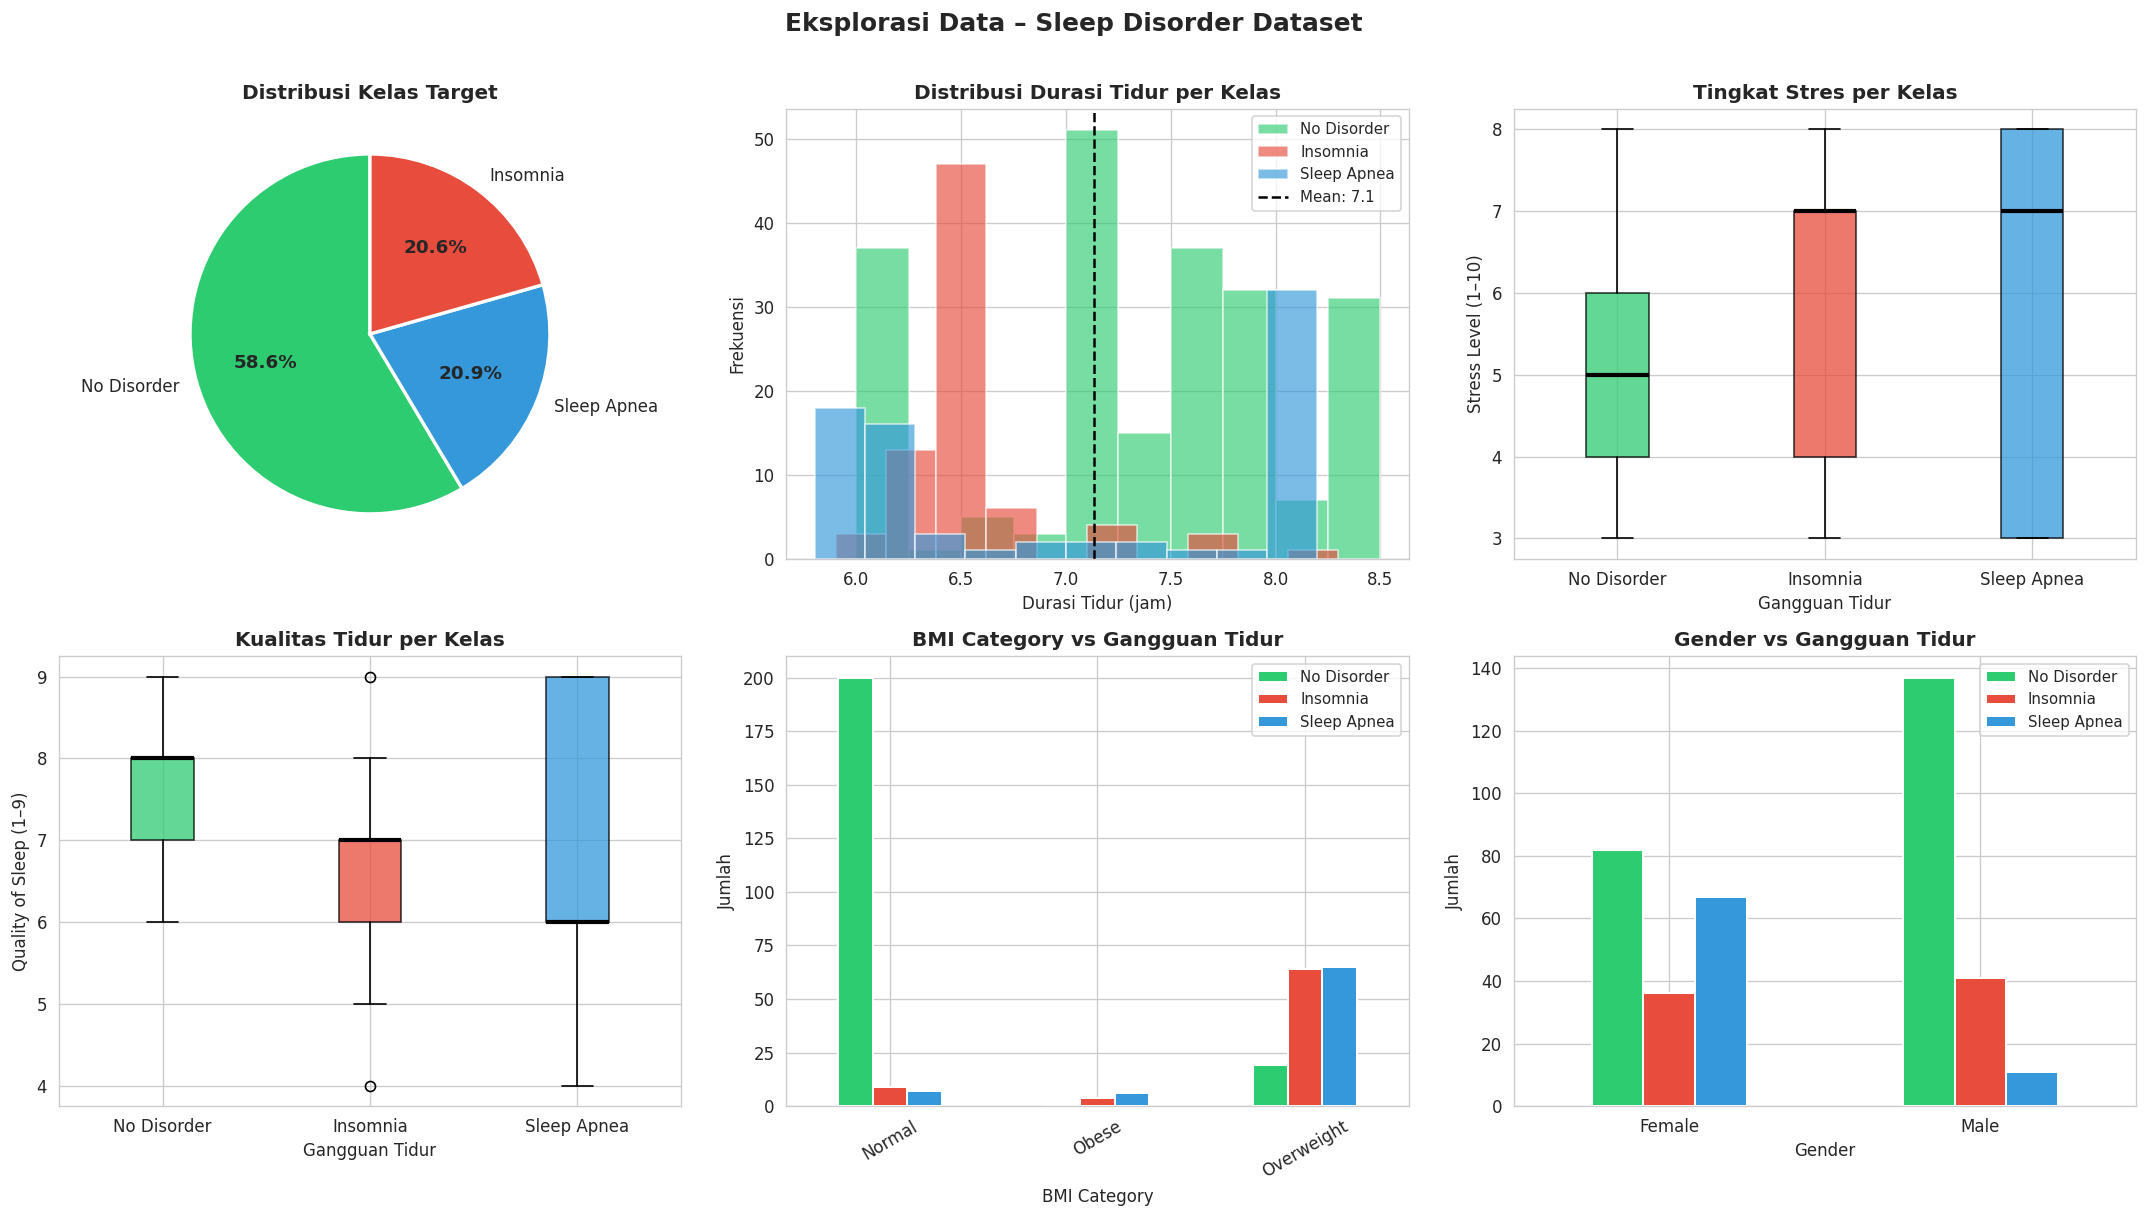

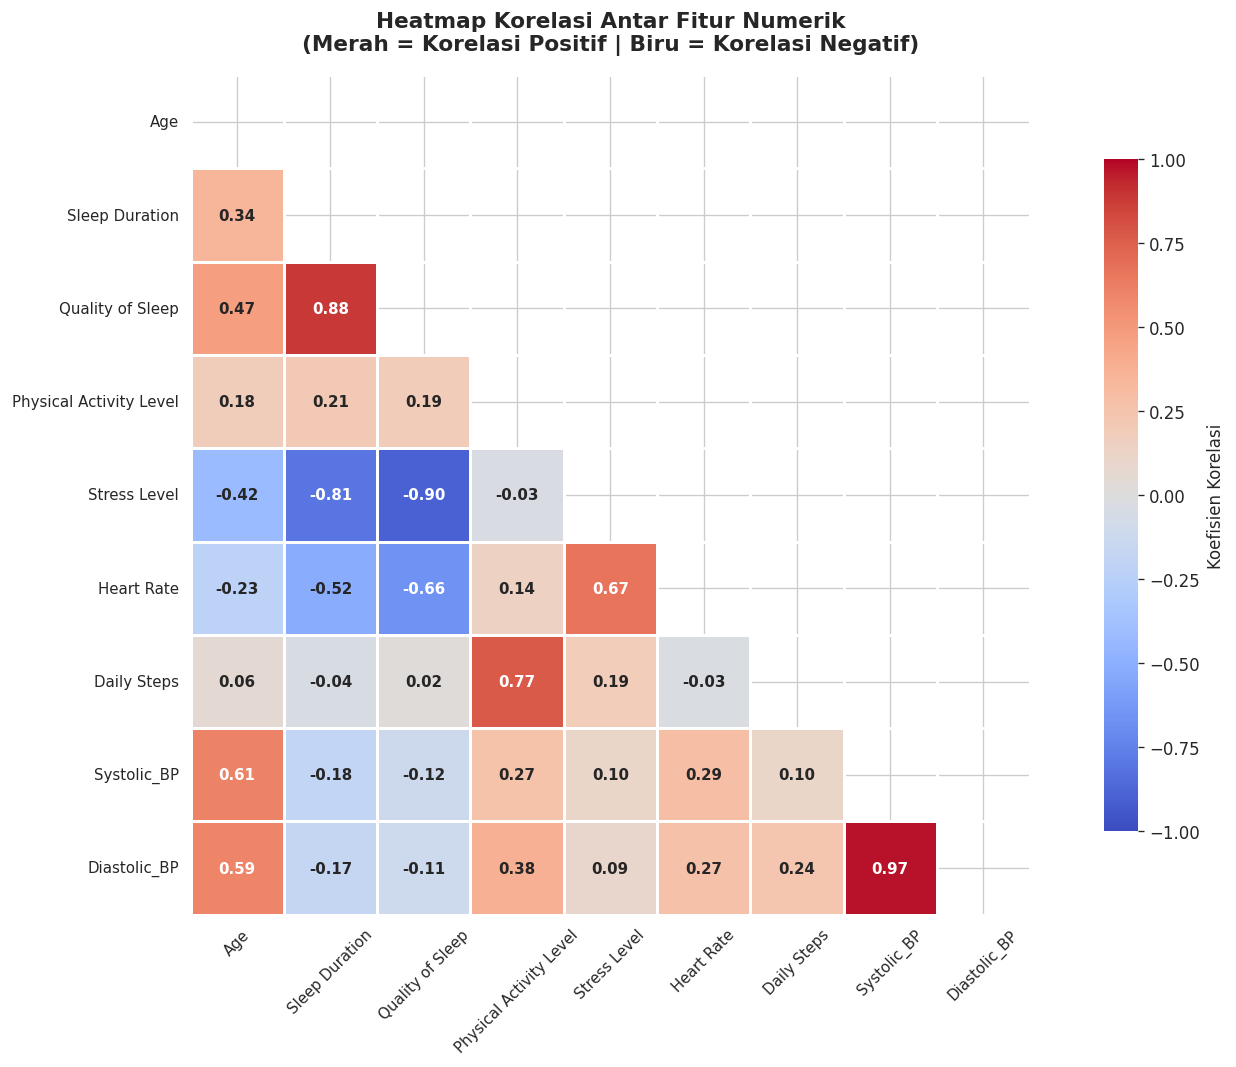

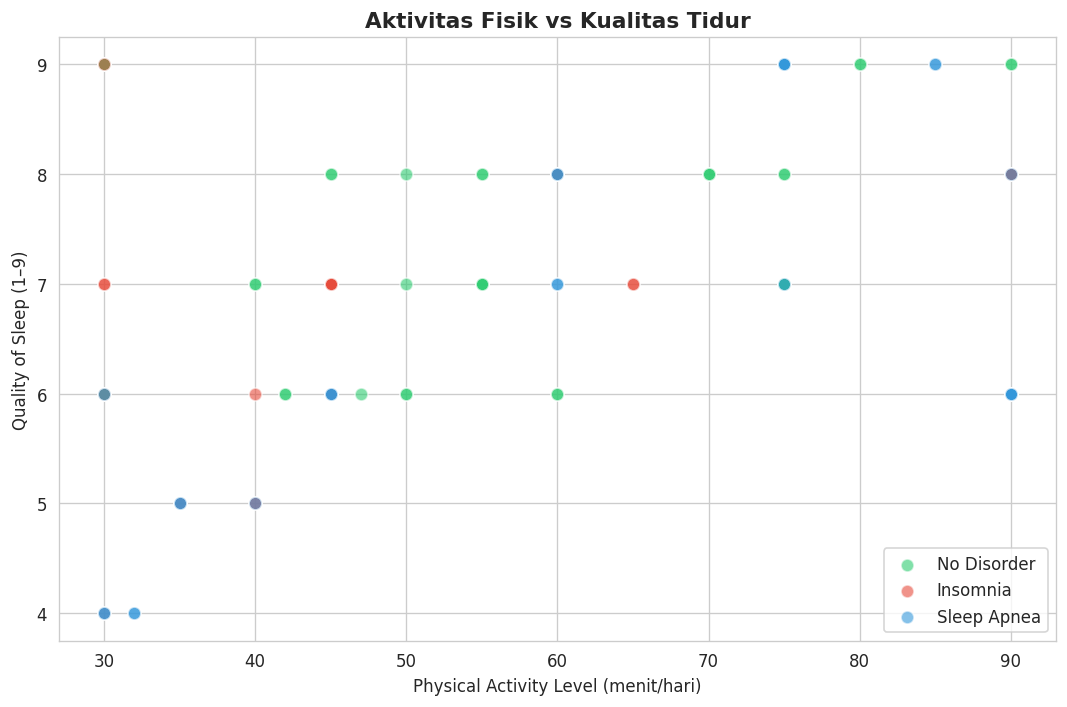


📌 INSIGHT PENTING DARI EDA:
  ① Distribusi kelas tidak seimbang: No Disorder (58.6%),
    Sleep Apnea (20.9%), Insomnia (20.6%)
    → Stratified Split digunakan untuk menjaga proporsi.
  ② Stress Level adalah pembeda terkuat antar kelas.
  ③ Quality of Sleep berkorelasi NEGATIF kuat dengan
    Stress Level (−0.90) dan POSITIF dengan Sleep Duration (+0.88).
  ④ BMI Obese cenderung mengalami Sleep Apnea.

✅ EDA selesai.


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 5 — TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 3 : EXPLORATORY DATA ANALYSIS (EDA)" + " "*19 + "║")
print("╚" + "═"*63 + "╝")

df_eda = df_raw.copy()
df_eda['BMI Category'] = df_eda['BMI Category'].replace('Normal Weight', 'Normal')
df_eda[['Systolic_BP', 'Diastolic_BP']] = (
    df_eda['Blood Pressure'].str.split('/', expand=True).astype(int))

ORDER = ['No Disorder', 'Insomnia', 'Sleep Apnea']

# ── EDA Plot A: Distribusi Kelas & Fitur Utama ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Eksplorasi Data – Sleep Disorder Dataset',
             fontsize=15, fontweight='bold', y=1.01)

# A1. Distribusi Target (Pie)
ax = axes[0, 0]
tc = df_eda['Sleep Disorder'].value_counts()
wedges, texts, autotexts = ax.pie(
    tc.values, labels=tc.index,
    colors=[C_CLASS[k] for k in tc.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(11)
ax.set_title('Distribusi Kelas Target', fontweight='bold', fontsize=12)

# A2. Distribusi Durasi Tidur per Kelas
ax = axes[0, 1]
for disorder, color in C_CLASS.items():
    data = df_eda[df_eda['Sleep Disorder'] == disorder]['Sleep Duration']
    ax.hist(data, bins=10, alpha=0.65, label=disorder,
            color=color, edgecolor='white')
ax.axvline(df_eda['Sleep Duration'].mean(), color='black',
           linestyle='--', linewidth=1.5,
           label=f'Mean: {df_eda["Sleep Duration"].mean():.1f}')
ax.set_title('Distribusi Durasi Tidur per Kelas', fontweight='bold', fontsize=12)
ax.set_xlabel('Durasi Tidur (jam)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# A3. Tingkat Stres per Kelas
ax = axes[0, 2]
bp = ax.boxplot([df_eda[df_eda['Sleep Disorder'] == d]['Stress Level'].values for d in ORDER],
                patch_artist=True, labels=ORDER,
                medianprops=dict(color='black', linewidth=2.5))
for patch, key in zip(bp['boxes'], ORDER):
    patch.set_facecolor(C_CLASS[key]); patch.set_alpha(0.75)
ax.set_title('Tingkat Stres per Kelas', fontweight='bold', fontsize=12)
ax.set_xlabel('Gangguan Tidur'); ax.set_ylabel('Stress Level (1–10)')

# A4. Kualitas Tidur per Kelas
ax = axes[1, 0]
bp2 = ax.boxplot([df_eda[df_eda['Sleep Disorder'] == d]['Quality of Sleep'].values for d in ORDER],
                 patch_artist=True, labels=ORDER,
                 medianprops=dict(color='black', linewidth=2.5))
for patch, key in zip(bp2['boxes'], ORDER):
    patch.set_facecolor(C_CLASS[key]); patch.set_alpha(0.75)
ax.set_title('Kualitas Tidur per Kelas', fontweight='bold', fontsize=12)
ax.set_xlabel('Gangguan Tidur'); ax.set_ylabel('Quality of Sleep (1–9)')

# A5. BMI Category vs Sleep Disorder
ax = axes[1, 1]
ct = pd.crosstab(df_eda['BMI Category'], df_eda['Sleep Disorder'])
ct = ct[[c for c in ORDER if c in ct.columns]]
ct.plot(kind='bar', ax=ax, color=[C_CLASS[c] for c in ct.columns],
        edgecolor='white', linewidth=1.2)
ax.set_title('BMI Category vs Gangguan Tidur', fontweight='bold', fontsize=12)
ax.set_xlabel('BMI Category'); ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=9)

# A6. Gender vs Sleep Disorder
ax = axes[1, 2]
ct2 = pd.crosstab(df_eda['Gender'], df_eda['Sleep Disorder'])
ct2 = ct2[[c for c in ORDER if c in ct2.columns]]
ct2.plot(kind='bar', ax=ax, color=[C_CLASS[c] for c in ct2.columns],
         edgecolor='white', linewidth=1.2)
ax.set_title('Gender vs Gangguan Tidur', fontweight='bold', fontsize=12)
ax.set_xlabel('Gender'); ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=0); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_1_distribusi.png', bbox_inches='tight')
plt.show()

# ── EDA Plot B: Heatmap Korelasi ──────────────────────────────────────
# PERBAIKAN: Heatmap sekarang memiliki visualisasi lengkap
#            dengan semua fitur numerik ditampilkan
fig, ax = plt.subplots(figsize=(13, 9))
num_eda = df_eda.select_dtypes(include=np.number).drop(
    columns=['Person ID'], errors='ignore')
corr = num_eda.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

hm = sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='coolwarm', annot=True, fmt='.2f',
    annot_kws={"size": 9, "weight": "bold"},
    linewidths=0.7, linecolor='white',
    vmin=-1, vmax=1, square=True,
    cbar_kws={"shrink": 0.8, "label": "Koefisien Korelasi"}
)

ax.set_title('Heatmap Korelasi Antar Fitur Numerik\n'
             '(Merah = Korelasi Positif | Biru = Korelasi Negatif)',
             fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('eda_2_heatmap.png', bbox_inches='tight')
plt.show()

# ── EDA Plot C: Scatter Aktivitas Fisik vs Kualitas Tidur ─────────────
fig, ax = plt.subplots(figsize=(9, 6))
for disorder, color in C_CLASS.items():
    subset = df_eda[df_eda['Sleep Disorder'] == disorder]
    ax.scatter(subset['Physical Activity Level'], subset['Quality of Sleep'],
               alpha=0.60, label=disorder, color=color,
               s=60, edgecolors='white')
ax.set_title('Aktivitas Fisik vs Kualitas Tidur', fontweight='bold', fontsize=13)
ax.set_xlabel('Physical Activity Level (menit/hari)')
ax.set_ylabel('Quality of Sleep (1–9)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_3_scatter.png', bbox_inches='tight')
plt.show()

print("""
📌 INSIGHT PENTING DARI EDA:
  ① Distribusi kelas tidak seimbang: No Disorder (58.6%),
    Sleep Apnea (20.9%), Insomnia (20.6%)
    → Stratified Split digunakan untuk menjaga proporsi.
  ② Stress Level adalah pembeda terkuat antar kelas.
  ③ Quality of Sleep berkorelasi NEGATIF kuat dengan
    Stress Level (−0.90) dan POSITIF dengan Sleep Duration (+0.88).
  ④ BMI Obese cenderung mengalami Sleep Apnea.
""")
print("✅ EDA selesai.")


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 6 — TAHAP 4: DATA SPLITTING (3 Rasio)
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 4 : DATA SPLITTING (3 Rasio)" + " "*27 + "║")
print("╚" + "═"*63 + "╝")

SPLIT_META = [
    {'key': '90:10', 'test': 0.10, 'label': '90% Train : 10% Test'},
    {'key': '80:20', 'test': 0.20, 'label': '80% Train : 20% Test'},
    {'key': '70:30', 'test': 0.30, 'label': '70% Train : 30% Test'},
]

splits = {}
for sp in SPLIT_META:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=sp['test'], random_state=42, stratify=y)
    sc      = StandardScaler()
    Xtr_sc  = sc.fit_transform(Xtr)
    Xte_sc  = sc.transform(Xte)
    splits[sp['key']] = {
        'Xtr': Xtr, 'Xte': Xte, 'ytr': ytr, 'yte': yte,
        'Xtr_sc': Xtr_sc, 'Xte_sc': Xte_sc,
        'sc': sc, 'label': sp['label'],
    }
    cls_dist = {CLASS_NAMES[i]: int((ytr == i).sum()) for i in range(3)}
    print(f"\n  📦 {sp['label']}")
    print(f"     Training : {len(Xtr):>3} sampel ({len(Xtr)/len(X)*100:.0f}%)")
    print(f"     Testing  : {len(Xte):>3} sampel ({len(Xte)/len(X)*100:.0f}%)")
    print(f"     Distribusi kelas training: {cls_dist}")

print("\n✅ Stratified Split digunakan — proporsi kelas terjaga di tiap set.")



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 4 : DATA SPLITTING (3 Rasio)                           ║
╚═══════════════════════════════════════════════════════════════╝

  📦 90% Train : 10% Test
     Training : 336 sampel (90%)
     Testing  :  38 sampel (10%)
     Distribusi kelas training: {'Insomnia': 69, 'No Disorder': 197, 'Sleep Apnea': 70}

  📦 80% Train : 20% Test
     Training : 299 sampel (80%)
     Testing  :  75 sampel (20%)
     Distribusi kelas training: {'Insomnia': 62, 'No Disorder': 175, 'Sleep Apnea': 62}

  📦 70% Train : 30% Test
     Training : 261 sampel (70%)
     Testing  : 113 sampel (30%)
     Distribusi kelas training: {'Insomnia': 54, 'No Disorder': 153, 'Sleep Apnea': 54}

✅ Stratified Split digunakan — proporsi kelas terjaga di tiap set.


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 7 — TAHAP 5 & 6: MODEL BUILDING + HYPERPARAMETER TUNING
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 5 : MODEL BUILDING                                     ║")
print("║  TAHAP 6 : HYPERPARAMETER TUNING (GridSearchCV 5-Fold)        ║")
print("╚" + "═"*63 + "╝")

print("""
  Algoritma yang digunakan:
    1. K-Nearest Neighbor  (KNN) — butuh normalisasi skala
    2. Decision Tree       (DT)  — berbasis pohon keputusan
    3. Random Forest       (RF)  — ensemble pohon keputusan

  Tuning  : GridSearchCV dengan Stratified K-Fold (k=5)
  Metrik  : Accuracy
""")

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definisi model + grid parameter tuning
ALGOS = {
    'KNN': {
        'label' : 'K-Nearest Neighbor',
        'base'  : KNeighborsClassifier(),
        'scaled': True,
        'grid'  : {
            'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
            'metric'     : ['euclidean', 'manhattan'],
            'weights'    : ['uniform', 'distance'],
        },
    },
    'DT': {
        'label' : 'Decision Tree',
        'base'  : DecisionTreeClassifier(random_state=42),
        'scaled': False,
        'grid'  : {
            'max_depth'        : [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 4],
            'criterion'        : ['gini', 'entropy'],
        },
    },
    'RF': {
        'label' : 'Random Forest',
        'base'  : RandomForestClassifier(random_state=42),
        'scaled': False,
        'grid'  : {
            'n_estimators'     : [50, 100, 200],
            'max_depth'        : [5, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf' : [1, 2],
        },
    },
}

# ── Training + Tuning semua kombinasi (3 algo × 3 split) ─────────────
print("\n  Melatih 3 algoritma × 3 rasio split = 9 eksperimen...\n")
RES = {s: {} for s in ALGOS}

for sp_key, sd in splits.items():
    ytb = label_binarize(sd['yte'], classes=[0, 1, 2])
    print(f"  ▶ Split {sp_key}  "
          f"(Train={len(sd['ytr'])} | Test={len(sd['yte'])})")

    for short, cfg in ALGOS.items():
        Xtr_ = sd['Xtr_sc'] if cfg['scaled'] else sd['Xtr'].values
        Xte_ = sd['Xte_sc'] if cfg['scaled'] else sd['Xte'].values

        gs = GridSearchCV(
            cfg['base'], cfg['grid'],
            cv=CV5, scoring='accuracy',
            n_jobs=-1, refit=True)
        gs.fit(Xtr_, sd['ytr'])

        mdl   = gs.best_estimator_
        yp    = mdl.predict(Xte_)
        yprob = mdl.predict_proba(Xte_)

        acc_te = accuracy_score(sd['yte'], yp)
        acc_tr = accuracy_score(sd['ytr'], mdl.predict(Xtr_))
        prec   = precision_score(sd['yte'], yp, average='macro', zero_division=0)
        rec    = recall_score(sd['yte'],   yp, average='macro', zero_division=0)
        f1     = f1_score(sd['yte'],       yp, average='macro', zero_division=0)
        auc_   = roc_auc_score(ytb, yprob, multi_class='ovr', average='macro')
        gap    = acc_tr - acc_te

        RES[short][sp_key] = {
            'model'     : mdl,
            'y_pred'    : yp,
            'y_prob'    : yprob,
            'y_test'    : sd['yte'],
            'y_test_bin': ytb,
            'acc_test'  : acc_te,
            'acc_train' : acc_tr,
            'cv_acc'    : gs.best_score_,
            'cv_std'    : gs.cv_results_['std_test_score'][gs.best_index_],
            'prec'      : prec,
            'rec'       : rec,
            'f1'        : f1,
            'auc'       : auc_,
            'cm'        : confusion_matrix(sd['yte'], yp),
            'params'    : gs.best_params_,
            'gap'       : gap,
        }

        flag = ('🟢 ≥95%' if acc_te >= 0.95 else
                '🟡 ≥90%' if acc_te >= 0.90 else
                '🔵 ≥85%' if acc_te >= 0.85 else '🔴 <85%')
        ovf  = '⚠ Overfit' if gap > 0.10 else '✅ Stabil'
        print(f"    {short}  Test={acc_te*100:.2f}%  "
              f"Train={acc_tr*100:.2f}%  Gap={gap:.4f}  "
              f"{flag}  {ovf}")

print("\n✅ Semua model selesai dilatih dan di-tuning.")

# ── Ringkasan Best Hyperparameter ─────────────────────────────────────
print("\n" + "─" * 65)
print("  📋 BEST HYPERPARAMETER HASIL GRIDSEARCHCV:")
print("─" * 65)
for short, cfg in ALGOS.items():
    print(f"\n  {cfg['label']} ({short}):")
    for sp_key in splits:
        print(f"    Split {sp_key}: {RES[short][sp_key]['params']}")



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 5 : MODEL BUILDING                                     ║
║  TAHAP 6 : HYPERPARAMETER TUNING (GridSearchCV 5-Fold)        ║
╚═══════════════════════════════════════════════════════════════╝

  Algoritma yang digunakan:
    1. K-Nearest Neighbor  (KNN) — butuh normalisasi skala
    2. Decision Tree       (DT)  — berbasis pohon keputusan
    3. Random Forest       (RF)  — ensemble pohon keputusan

  Tuning  : GridSearchCV dengan Stratified K-Fold (k=5)
  Metrik  : Accuracy


  Melatih 3 algoritma × 3 rasio split = 9 eksperimen...

  ▶ Split 90:10  (Train=336 | Test=38)
    KNN  Test=94.74%  Train=88.99%  Gap=-0.0575  🟡 ≥90%  ✅ Stabil
    DT  Test=97.37%  Train=91.67%  Gap=-0.0570  🟢 ≥95%  ✅ Stabil
    RF  Test=97.37%  Train=92.56%  Gap=-0.0481  🟢 ≥95%  ✅ Stabil
  ▶ Split 80:20  (Train=299 | Test=75)
    KNN  Test=94.67%  Train=88.96%  Gap=-0.0570  🟡 ≥90%  ✅ Stabil
    DT  Test=93.33%  Train=90.97%  Gap=-0.0236  🟡 


╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 7 : MODEL EVALUATION                                   ║
╚═══════════════════════════════════════════════════════════════╝

  Composite score per split: {'90:10': np.float64(0.9657544016920592), '80:20': np.float64(0.948623889419698), '70:30': np.float64(0.9260882405853635)}
  → Split terpilih untuk evaluasi detail: 90:10

─────────────────────────────────────────────────────────────────
  CLASSIFICATION REPORT — Split 90:10
─────────────────────────────────────────────────────────────────

  🥇 Decision Tree (DT)
     Best Params  : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
     Train Acc    : 0.9167  (91.67%)
     Test  Acc    : 0.9737  (97.37%)
     Gap          : -0.0570  → ✅ Generalisasi Baik
     CV Accuracy  : 0.8868 ± 0.0264
     Precision    : 0.9630
     Recall       : 0.9583
     F1-Score     : 0.9582
     AUC-ROC      : 1.0000
              precision    

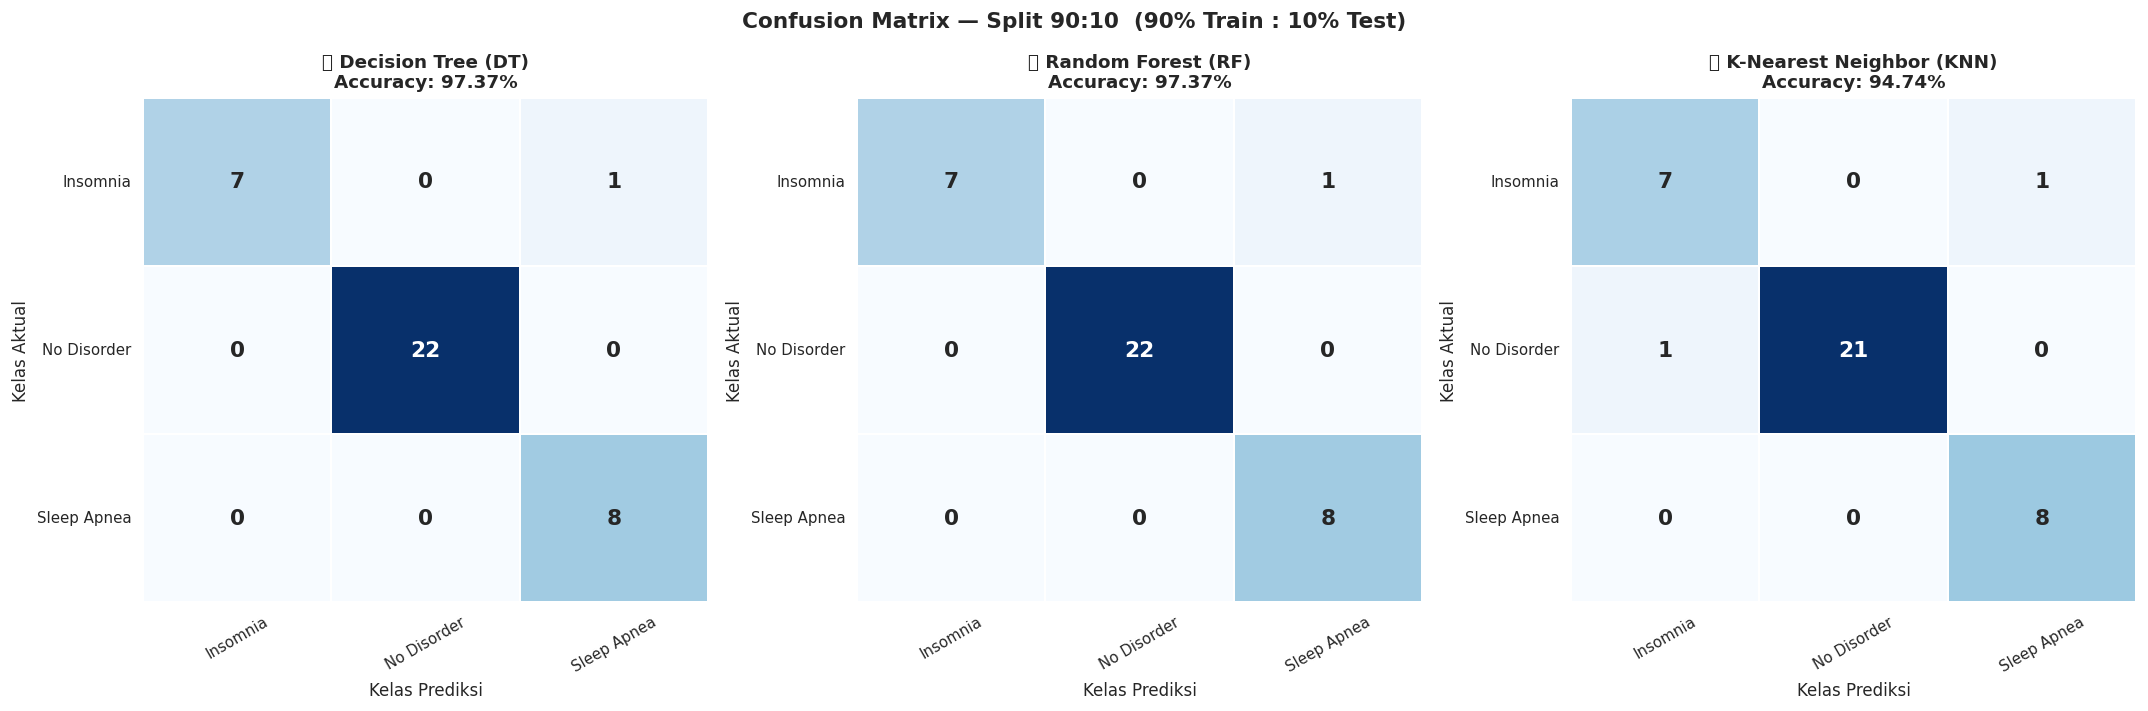


─────────────────────────────────────────────────────────────────
  CEK OVERFITTING — LEARNING CURVE
─────────────────────────────────────────────────────────────────


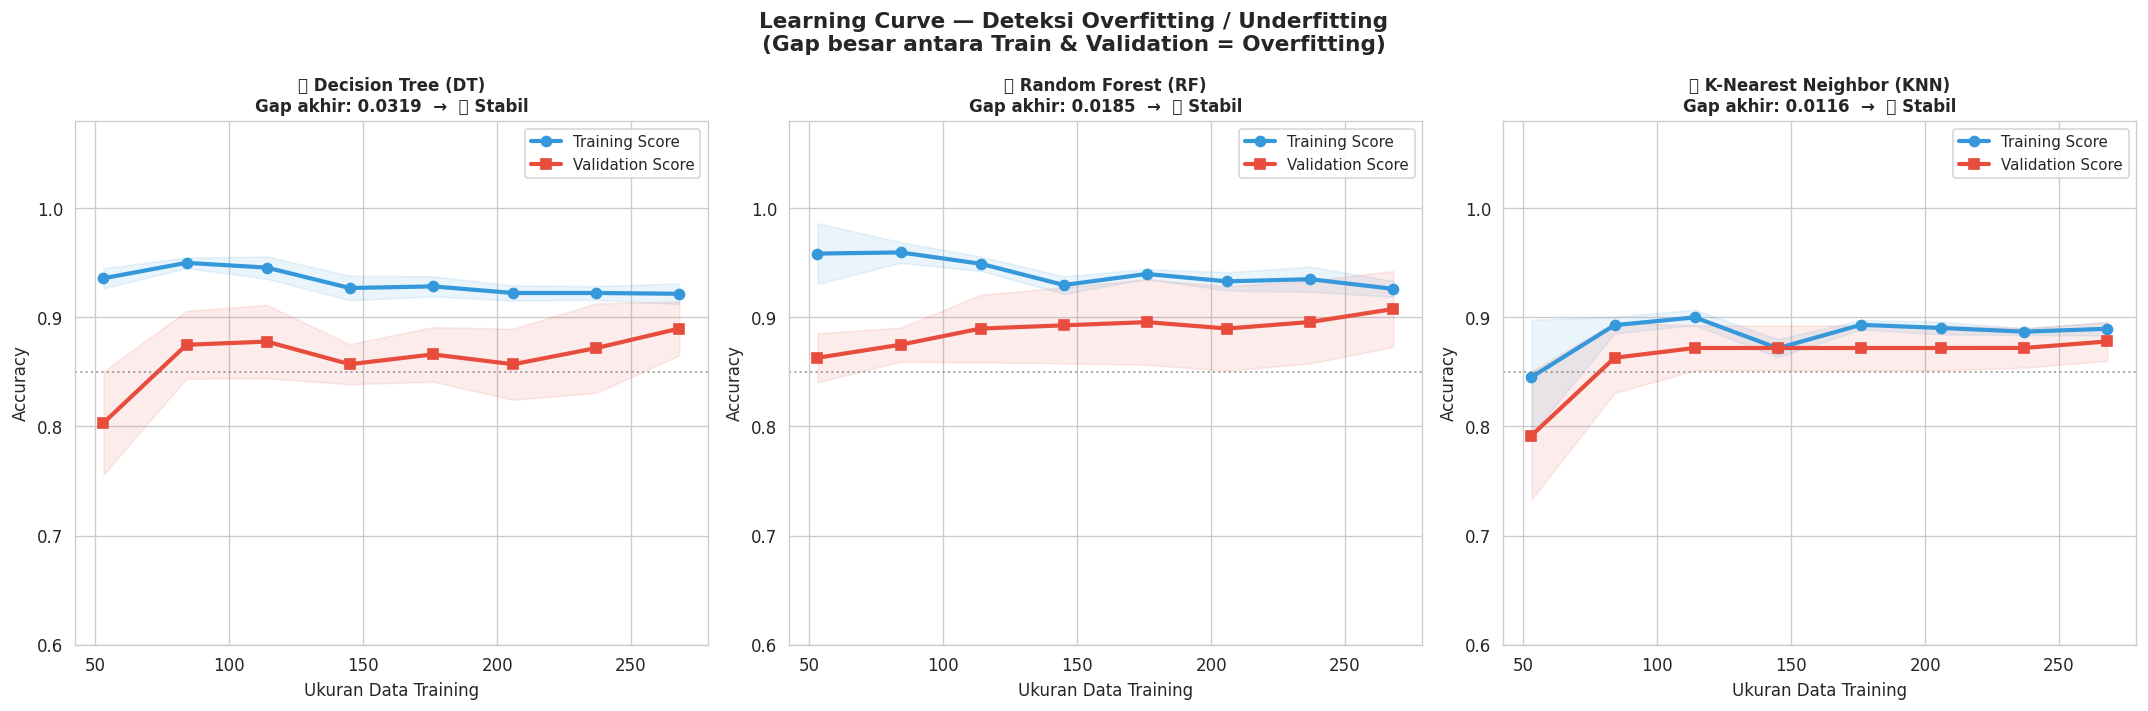


  STATUS OVERFITTING (Split Terpilih: 90:10)
  ──────────────────────────────────────────────────────────
  Decision Tree            : Train=0.9167 | Test=0.9737 | Gap=-0.0570  →  ✅ GENERALISASI BAIK
  Random Forest            : Train=0.9256 | Test=0.9737 | Gap=-0.0481  →  ✅ GENERALISASI BAIK
  K-Nearest Neighbor       : Train=0.8899 | Test=0.9474 | Gap=-0.0575  →  ✅ GENERALISASI BAIK


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 8 — TAHAP 7: MODEL EVALUATION
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 7 : MODEL EVALUATION" + " "*35 + "║")
print("╚" + "═"*63 + "╝")

# Pilih split terbaik berdasarkan composite score
best_split_score = {}
for sp_key in splits:
    comp = np.mean([
        0.50 * RES[s][sp_key]['acc_test'] +
        0.30 * RES[s][sp_key]['f1']       +
        0.20 * RES[s][sp_key]['auc']
        for s in ALGOS
    ])
    best_split_score[sp_key] = comp

BEST_SPLIT = max(best_split_score, key=best_split_score.get)
ranked     = sorted(ALGOS, key=lambda s: RES[s][BEST_SPLIT]['acc_test'], reverse=True)

print(f"\n  Composite score per split: {best_split_score}")
print(f"  → Split terpilih untuk evaluasi detail: {BEST_SPLIT}\n")

# ── 7A: Classification Report ─────────────────────────────────────────
print("─" * 65)
print(f"  CLASSIFICATION REPORT — Split {BEST_SPLIT}")
print("─" * 65)
for short, medal in zip(ranked, MEDALS):
    r   = RES[short][BEST_SPLIT]
    ovf = '⚠ Potensi Overfitting' if r['gap'] > 0.10 else '✅ Generalisasi Baik'
    print(f"\n  {medal} {ALGOS[short]['label']} ({short})")
    print(f"     Best Params  : {r['params']}")
    print(f"     Train Acc    : {r['acc_train']:.4f}  ({r['acc_train']*100:.2f}%)")
    print(f"     Test  Acc    : {r['acc_test']:.4f}  ({r['acc_test']*100:.2f}%)")
    print(f"     Gap          : {r['gap']:.4f}  → {ovf}")
    print(f"     CV Accuracy  : {r['cv_acc']:.4f} ± {r['cv_std']:.4f}")
    print(f"     Precision    : {r['prec']:.4f}")
    print(f"     Recall       : {r['rec']:.4f}")
    print(f"     F1-Score     : {r['f1']:.4f}")
    print(f"     AUC-ROC      : {r['auc']:.4f}")
    print(classification_report(r['y_test'], r['y_pred'],
                                target_names=CLASS_NAMES, digits=4))

# ── 7B: Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Confusion Matrix — Split {BEST_SPLIT}  '
             f'({splits[BEST_SPLIT]["label"]})',
             fontsize=13, fontweight='bold')

for ax, short, medal, rc in zip(axes, ranked, MEDALS, RANK_C):
    r = RES[short][BEST_SPLIT]
    sns.heatmap(r['cm'], annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=1.0, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={'size': 13, 'weight': 'bold'})
    for sp in ax.spines.values():
        sp.set_edgecolor(rc); sp.set_linewidth(4)
    ax.set_title(f"{medal} {ALGOS[short]['label']} ({short})\n"
                 f"Accuracy: {r['acc_test']*100:.2f}%",
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Kelas Prediksi', fontsize=10)
    ax.set_ylabel('Kelas Aktual',   fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('eval_1_confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── 7C: Learning Curve — Cek Overfitting / Underfitting ──────────────
print("\n" + "─" * 65)
print("  CEK OVERFITTING — LEARNING CURVE")
print("─" * 65)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Learning Curve — Deteksi Overfitting / Underfitting\n'
             '(Gap besar antara Train & Validation = Overfitting)',
             fontsize=13, fontweight='bold')

sd_best     = splits[BEST_SPLIT]
train_sizes = np.linspace(0.2, 1.0, 8)

for ax, short, medal in zip(axes, ranked, MEDALS):
    cfg  = ALGOS[short]
    mdl  = RES[short][BEST_SPLIT]['model']
    Xtr_ = sd_best['Xtr_sc'] if cfg['scaled'] else sd_best['Xtr'].values
    ytr_ = sd_best['ytr']

    ts, tr_sc, val_sc = learning_curve(
        mdl, Xtr_, ytr_,
        train_sizes=train_sizes, cv=CV5,
        scoring='accuracy', n_jobs=-1)

    tr_m  = tr_sc.mean(1);  tr_s  = tr_sc.std(1)
    val_m = val_sc.mean(1); val_s = val_sc.std(1)

    ax.plot(ts, tr_m,  'o-', color='#3498DB', lw=2.5, label='Training Score')
    ax.plot(ts, val_m, 's-', color='#E74C3C', lw=2.5, label='Validation Score')
    ax.fill_between(ts, tr_m - tr_s,  tr_m + tr_s,  alpha=0.10, color='#3498DB')
    ax.fill_between(ts, val_m - val_s, val_m + val_s, alpha=0.10, color='#E74C3C')

    final_gap = tr_m[-1] - val_m[-1]
    status    = ('⚠ Overfitting'  if final_gap > 0.10 else
                 '✅ Stabil'      if val_m[-1] > 0.80  else '⚠ Underfitting')

    ax.set_title(f"{medal} {ALGOS[short]['label']} ({short})\n"
                 f"Gap akhir: {final_gap:.4f}  →  {status}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Ukuran Data Training', fontsize=10)
    ax.set_ylabel('Accuracy',            fontsize=10)
    ax.set_ylim(0.60, 1.08)
    ax.legend(fontsize=9)
    ax.axhline(0.85, color='gray', linestyle=':', lw=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig('eval_4_learning_curve.png', bbox_inches='tight')
plt.show()


print("\n  STATUS OVERFITTING (Split Terpilih: {})".format(BEST_SPLIT))
print("  " + "─" * 58)
for short in ranked:
    r   = RES[short][BEST_SPLIT]
    gap = r['gap']
    if gap > 0.10:
        status = "⚠️  OVERFITTING   — gap besar, model terlalu hafal training"
    elif r['acc_test'] < 0.75:
        status = "⚠️  UNDERFITTING  — akurasi terlalu rendah"
    else:
        status = "✅ GENERALISASI BAIK"
    print(f"  {ALGOS[short]['label']:<25}: "
          f"Train={r['acc_train']:.4f} | Test={r['acc_test']:.4f} | "
          f"Gap={gap:.4f}  →  {status}")


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 9 — TAHAP 8: MODEL COMPARISON
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  TAHAP 8 : MODEL COMPARISON" + " "*35 + "║")
print("╚" + "═"*63 + "╝")

# ── 8A: Perbandingan Akurasi & Metrik per Split ───────────────────────
print("\n  PERBANDINGAN ALGORITMA vs RASIO SPLIT")
print("─" * 65)
final_results = []
for short, cfg in ALGOS.items():
    for sp_key in splits:
        r = RES[short][sp_key]
        ovf_status = "Overfitting" if r['gap'] > 0.10 else "Normal"
        final_results.append({
            'Algoritma'     : ALGOS[short]['label'],
            'Split'         : sp_key,
            'Train Accuracy': round(r['acc_train'], 4),
            'Test Accuracy' : round(r['acc_test'],  4),
            'Gap'           : round(r['gap'],        4),
            'Status'        : ovf_status,
        })

final_df = pd.DataFrame(final_results).sort_values(
    ['Algoritma', 'Test Accuracy'], ascending=[True, False])

print("\n  📊 TABEL PERBANDINGAN ALGORITMA × SPLIT:")
display(final_df.reset_index(drop=True))



print("✅ Semua visualisasi Model Comparison selesai.")



╔═══════════════════════════════════════════════════════════════╗
║  TAHAP 8 : MODEL COMPARISON                                   ║
╚═══════════════════════════════════════════════════════════════╝

  PERBANDINGAN ALGORITMA vs RASIO SPLIT
─────────────────────────────────────────────────────────────────

  📊 TABEL PERBANDINGAN ALGORITMA × SPLIT:


,Algoritma,Split,Train Accuracy,Test Accuracy,Gap,Status
0,Decision Tree,90:10,0.9167,0.9737,-0.0570,Normal
1,Decision Tree,80:20,0.9097,0.9333,-0.0236,Normal
2,Decision Tree,70:30,0.9004,0.9204,-0.0200,Normal
3,K-Nearest Neighbor,90:10,0.8899,0.9474,-0.0575,Normal
4,K-Nearest Neighbor,80:20,0.8896,0.9467,-0.0570,Normal
5,K-Nearest Neighbor,70:30,0.9042,0.9204,-0.0161,Normal
6,Random Forest,90:10,0.9256,0.9737,-0.0481,Normal
7,Random Forest,80:20,0.9164,0.9600,-0.0436,Normal
8,Random Forest,70:30,0.9195,0.9469,-0.0274,Normal


✅ Semua visualisasi Model Comparison selesai.


In [ ]:
 import joblib

# Select the best model (Decision Tree from the best split) and the corresponding scaler
model_terbaik = RES[ranked[0]][BEST_SPLIT]['model']
scaler = splits[BEST_SPLIT]['sc']

joblib.dump(model_terbaik, 'model_sleep.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_gender, 'le_gender.pkl')
joblib.dump(le_occ, 'le_occ.pkl')
joblib.dump(le_bmi, 'le_bmi.pkl')
joblib.dump(le_target, 'le_target.pkl')

print("✅ Model dan encoder berhasil disimpan!")

✅ Model dan encoder berhasil disimpan!



╔═══════════════════════════════════════════════════════════════╗
║  INFERENCE — PREDIKSI RISIKO GANGGUAN TIDUR PASIEN BARU      ║
╚═══════════════════════════════════════════════════════════════╝

  Inference = menggunakan model terlatih terbaik untuk
  memprediksi data pasien baru yang belum pernah dilihat model.

  ┌──────────────────────────────────────────────────────────┐
  │  Profil Pasien:                                          │
  │  • Perempuan, usia 38 tahun, Pekerjaan: Guru            │
  │  • Durasi tidur: 5.8 jam (di bawah rata-rata)           │
  │  • Kualitas tidur: 5/9  |  Tingkat stres: 8/10          │
  │  • Aktivitas fisik: 25 menit/hari (rendah)              │
  │  • BMI: Overweight  |  Heart Rate: 82 bpm               │
  │  • Blood Pressure: 135/88 mmHg                          │
  └──────────────────────────────────────────────────────────┘

📥 Data Pasien (sebelum encoding):


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
0,Female,38,Teacher,5.8,5,25,8,Overweight,82,4200,135,88



🎯 HASIL PREDIKSI DARI 3 ALGORITMA:

  Algoritma                    Prediksi             Confidence
  ────────────────────────────────────────────────────────────
  K-Nearest Neighbor           Sleep Apnea             54.55%
  Decision Tree                Sleep Apnea            100.00%
  Random Forest                Sleep Apnea             57.20%

📊 Probabilitas per Kelas:
  Algoritma                     Insomnia            No Disorder         Sleep Apnea       
  ────────────────────────────────────────────────────────────────────────────────
  K-Nearest Neighbor            0.2727              0.1818              0.5455            
  Decision Tree                 0.0000              0.0000              1.0000            
  Random Forest                 0.3728              0.0552              0.5720            

  ▶ Kesimpulan Prediksi : Sleep Apnea  (semua algoritma sepakat)
  ▶ Interpretasi       : Pasien berisiko mengalami SLEEP APNEA.
                         Disarankan: periksa ke

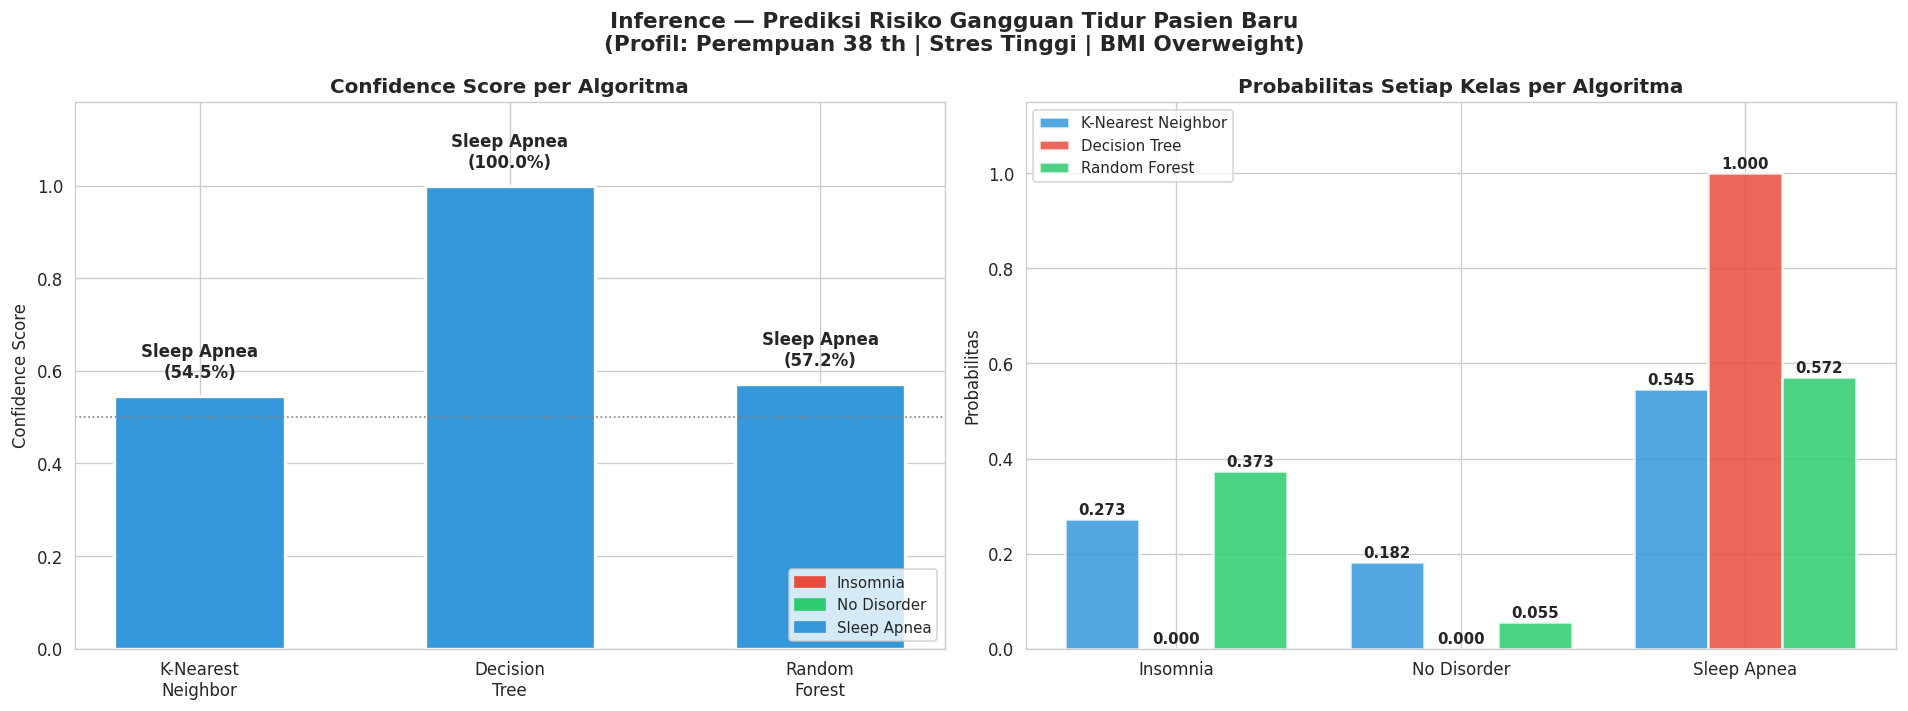


✅ Inference selesai — model siap digunakan pada data baru!


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 10 — INFERENCE (Prediksi Data Pasien Baru)
# ════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═"*63 + "╗")
print("║  INFERENCE — PREDIKSI RISIKO GANGGUAN TIDUR PASIEN BARU" + " "*6 + "║")
print("╚" + "═"*63 + "╝")

print("""
  Inference = menggunakan model terlatih terbaik untuk
  memprediksi data pasien baru yang belum pernah dilihat model.

  ┌──────────────────────────────────────────────────────────┐
  │  Profil Pasien:                                          │
  │  • Perempuan, usia 38 tahun, Pekerjaan: Guru            │
  │  • Durasi tidur: 5.8 jam (di bawah rata-rata)           │
  │  • Kualitas tidur: 5/9  |  Tingkat stres: 8/10          │
  │  • Aktivitas fisik: 25 menit/hari (rendah)              │
  │  • BMI: Overweight  |  Heart Rate: 82 bpm               │
  │  • Blood Pressure: 135/88 mmHg                          │
  └──────────────────────────────────────────────────────────┘
""")

# ── Input Data Baru ────────────────────────────────────────────────────
data_baru = pd.DataFrame([{
    'Gender'                : 'Female',
    'Age'                   : 38,
    'Occupation'            : 'Teacher',
    'Sleep Duration'        : 5.8,
    'Quality of Sleep'      : 5,
    'Physical Activity Level': 25,
    'Stress Level'          : 8,
    'BMI Category'          : 'Overweight',
    'Heart Rate'            : 82,
    'Daily Steps'           : 4200,
    'Systolic_BP'           : 135,
    'Diastolic_BP'          : 88,
}])

print("📥 Data Pasien (sebelum encoding):")
display(data_baru)

# ── Preprocessing (harus identik dengan training) ──────────────────────
data_proc = data_baru.copy()
data_proc['Gender']       = le_gender.transform(data_proc['Gender'])
data_proc['Occupation']   = le_occ.transform(data_proc['Occupation'])
data_proc['BMI Category'] = le_bmi.transform(data_proc['BMI Category'])
data_proc = data_proc[FEATURE_NAMES]     # pastikan urutan kolom sama

# Scaling untuk KNN
data_scaled = splits[BEST_SPLIT]['sc'].transform(data_proc)

print("\n🎯 HASIL PREDIKSI DARI 3 ALGORITMA:\n")
print(f"  {'Algoritma':<28} {'Prediksi':<20} {'Confidence':>10}")
print("  " + "─" * 60)

infer_res = {}
for short, cfg in ALGOS.items():
    mdl_      = RES[short][BEST_SPLIT]['model']
    X_input   = data_scaled if cfg['scaled'] else data_proc.values
    pred_idx  = mdl_.predict(X_input)[0]
    pred_prob = mdl_.predict_proba(X_input)[0]
    pred_cls  = CLASS_NAMES[pred_idx]
    conf      = pred_prob[pred_idx]
    infer_res[short] = {'pred': pred_cls, 'conf': conf, 'prob': pred_prob}
    print(f"  {ALGOS[short]['label']:<28} {pred_cls:<20} {conf*100:>8.2f}%")

print("\n📊 Probabilitas per Kelas:")
print(f"  {'Algoritma':<28}", end='')
for cls in CLASS_NAMES:
    print(f"  {cls:<18}", end='')
print()
print("  " + "─" * 80)
for short in ALGOS:
    print(f"  {ALGOS[short]['label']:<28}", end='')
    for prob in infer_res[short]['prob']:
        print(f"  {prob:.4f}            ", end='')
    print()

# Kesimpulan inference
votes    = [infer_res[s]['pred'] for s in ALGOS]
majority = Counter(votes).most_common(1)[0][0]
agree    = "semua algoritma sepakat" if len(set(votes))==1 else "mayoritas 2/3"

print(f"\n  ▶ Kesimpulan Prediksi : {majority}  ({agree})")
print(f"  ▶ Interpretasi       : ", end='')
if majority == 'Insomnia':
    print("Pasien berisiko mengalami INSOMNIA.\n"
          "                         Disarankan: evaluasi manajemen stres,\n"
          "                         perbaiki jadwal tidur, konsultasi dokter.")
elif majority == 'Sleep Apnea':
    print("Pasien berisiko mengalami SLEEP APNEA.\n"
          "                         Disarankan: periksa ke dokter spesialis\n"
          "                         tidur, perhatikan posisi tidur & BMI.")
else:
    print("Pasien TIDAK terindikasi gangguan tidur serius.\n"
          "                         Tetap jaga pola tidur & gaya hidup sehat.")

# ── Visualisasi Inference ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Inference — Prediksi Risiko Gangguan Tidur Pasien Baru\n'
             f'(Profil: Perempuan 38 th | Stres Tinggi | BMI Overweight)',
             fontsize=13, fontweight='bold')

# Kiri: Bar confidence per algoritma
ax = axes[0]
confs_  = [infer_res[s]['conf'] for s in ALGOS]
colors_ = [C_CLASS.get(infer_res[s]['pred'], '#95A5A6') for s in ALGOS]
bars    = ax.bar([ALGOS[s]['label'].replace(' ', '\n') for s in ALGOS],
                 confs_, color=colors_, edgecolor='white', lw=2, width=0.55)
ax.set_ylim(0, 1.18)
ax.set_title('Confidence Score per Algoritma', fontweight='bold', fontsize=12)
ax.set_ylabel('Confidence Score')
ax.axhline(0.5, color='gray', linestyle=':', lw=1)
for bar, s in zip(bars, ALGOS):
    pred = infer_res[s]['pred']
    conf = infer_res[s]['conf']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{pred}\n({conf*100:.1f}%)', ha='center',
            fontsize=10, fontweight='bold')
patches_ = [mpatches.Patch(color=C_CLASS[c], label=c) for c in CLASS_NAMES]
ax.legend(handles=patches_, fontsize=9, loc='lower right')

# Kanan: Grouped bar probabilitas semua kelas
ax = axes[1]
x_inf = np.arange(len(CLASS_NAMES))
w_inf = 0.26
for i, (short, sp_col) in enumerate(C_ALGO.items()):
    probs_ = infer_res[short]['prob']
    b = ax.bar(x_inf + (i-1)*w_inf, probs_, w_inf,
               label=ALGOS[short]['label'], color=sp_col,
               alpha=0.85, edgecolor='white', lw=1.5)
    for bar, val in zip(b, probs_):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x_inf)
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Probabilitas Setiap Kelas per Algoritma', fontweight='bold', fontsize=12)
ax.set_ylabel('Probabilitas')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('inference_prediksi.png', bbox_inches='tight')
plt.show()

print("\n✅ Inference selesai — model siap digunakan pada data baru!")
